# Hidden Pairs: обучение, оценка и сохранение моделей

## Настройка

In [1]:
DOWNLOAD_DATA = False
if DOWNLOAD_DATA:
    import kagglehub

    # Download latest version
    path = kagglehub.competition_download('week-03-hidden-pairs')
    print("Path to competition files:", path)

In [2]:
import pandas as pd
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier, early_stopping
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import roc_auc_score
from pathlib import Path
import time
# import cleanlab
import json
from datetime import datetime

import joblib
from importlib.metadata import version

PACKAGE_VERSIONS = {name: version(name) for name in [
    "numpy", "pandas", "scikit-learn", "lightgbm", "joblib", "torch",
]}
print(PACKAGE_VERSIONS)
from dataclasses import replace

{'numpy': '2.5.3', 'pandas': '3.0.6', 'scikit-learn': '1.9.1', 'lightgbm': '4.7.0', 'joblib': '1.6.0', 'torch': '2.14.0'}


In [3]:
def set_seed(seed=42):
    """Фиксирует seed для random, NumPy и PyTorch, включая CUDA."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    torch.use_deterministic_algorithms(True, warn_only=True)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    print(f'Seed: {seed}')

In [4]:
SEED = 42
set_seed(SEED)

LOCAL = not Path('/kaggle/input').exists()

LOG_DIR = Path('./logs') if LOCAL else Path('/kaggle/working/logs')

OUTPUT_DIR = Path('.') if LOCAL else Path('/kaggle/working')
RUN_SEARCH = False
RUN_CLEANLAB = False
EARLY_STOPPING_ROUNDS = 500  # Длинное плато на validation возможно перед новым ростом.

Seed: 42


## Данные
Используются исходные признаки без агрегатов. Состав и порядок признаков при предсказании должны совпадать с обучением.

In [5]:
DATA_DIR = Path(path) if DOWNLOAD_DATA else (
    Path('./data') if LOCAL else Path('/kaggle/input/competitions/week-03-hidden-pairs')
)

train_df: pd.DataFrame = pd.read_csv(DATA_DIR / 'train.csv')
val_df: pd.DataFrame = pd.read_csv(DATA_DIR / 'validation.csv')
test_df: pd.DataFrame = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission: pd.DataFrame = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)
print("sample submission:", sample_submission.shape)

train: (2520, 514)
val: (560, 514)
test: (1116, 513)
sample submission: (1116, 2)


In [6]:
assert train_df.isna().sum().sum() == 0, "train_df contains NaN values"
assert val_df.isna().sum().sum() == 0, "val_df contains NaN values"
assert test_df.isna().sum().sum() == 0, "test_df contains NaN values"

assert train_df['row_id'].is_unique, "train_df contains duplicate ids"
assert val_df['row_id'].is_unique, "val_df contains duplicate ids"
assert test_df['row_id'].is_unique, "test_df contains duplicate ids"

In [7]:
feature_columns: list[str] = [
    col for col in train_df.columns if col not in ['row_id', 'target']
]

assert feature_columns == [c for c in val_df if c not in ['row_id', 'target']]
assert feature_columns == [c for c in test_df if c != 'row_id']
for frame in [train_df, val_df, test_df]:
    assert np.isfinite(frame[feature_columns].to_numpy()).all(), 'Признаки содержат NaN/inf'

X_train: pd.DataFrame = train_df[feature_columns]
y_train: pd.Series = train_df['target']

X_val: pd.DataFrame = val_df[feature_columns]
y_val: pd.Series = val_df['target']

X_test: pd.DataFrame = test_df[feature_columns]

print('# of features:', len(feature_columns))
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_val shape:', X_val.shape)
print('y_val shape:', y_val.shape)
print('X_test shape:', X_test.shape)

# of features: 512
X_train shape: (2520, 512)
y_train shape: (2520,)
X_val shape: (560, 512)
y_val shape: (560,)
X_test shape: (1116, 512)


## Feature Engineering

In [21]:
def aggregate_features(df: pd.DataFrame) -> pd.DataFrame:
    """Заменяет признаки каждой строки статистиками, сохраняя индекс.

    row_id и target исключаются. total — сумма значений признаков.
    Пропуски игнорируются; std и var используют ddof=1.
    """
    vals = df.drop(columns=['row_id', 'target'], errors='ignore')
    mean = vals.mean(axis=1)
    total = vals.sum(axis=1, min_count=1)

    return pd.DataFrame({
        'total': total,
        'count_zeros': vals.eq(0).sum(axis=1),
        'relative_std': vals.std(axis=1) / mean.replace(0, np.nan),
        'max_share': vals.max(axis=1) / total.replace(0, np.nan),
        'q90_median_ratio': (
            vals.quantile(0.9, axis=1)
            / vals.median(axis=1).replace(0, np.nan)
        ),
        'max': vals.max(axis=1),
        'log1p_sum': np.log1p(vals).sum(axis=1, min_count=1),
    }, index=df.index)  

def add_aggregate_features(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет статистики к исходным признакам, исключая row_id и target."""
    vals = df.drop(columns=['row_id', 'target'], errors='ignore')
    aggregated = aggregate_features(vals)
    return pd.concat([vals, aggregated], axis=1)

X_train_extended = add_aggregate_features(X_train)
X_val_extended = add_aggregate_features(X_val)
X_test_extended = add_aggregate_features(X_test)

for features in [X_train_extended, X_val_extended, X_test_extended]:
    assert features.columns.is_unique, 'Повторяющиеся признаки'
    assert np.isfinite(features.to_numpy()).all(), 'Агрегации содержат NaN/inf'

X_train_extended.describe()

,f0000,f0001,f0002,f0003,f0004,f0005,f0006,f0007,f0008,f0009,...,f0509,f0510,f0511,total,count_zeros,relative_std,max_share,q90_median_ratio,max,log1p_sum
count,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,...,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000
mean,0.816421,0.351254,0.410664,0.298792,0.316071,0.829884,0.794327,0.458188,0.534329,0.508600,...,0.888112,0.891143,0.305156,268.232170,3.331746,1.066966,0.014720,3.610789,3.948773,183.835999
std,0.770276,0.422683,0.475670,0.359389,0.351609,0.735614,0.750005,0.451543,0.604170,0.657583,...,0.876417,0.794348,0.397978,109.880246,6.356445,0.092933,0.003388,0.496284,1.809158,63.941095
min,0.000914,0.000000,0.000000,0.000000,0.000000,0.000149,0.000000,0.000000,0.000000,0.000000,...,0.000146,0.000000,0.000000,2.410557,0.000000,0.859895,0.008546,2.565496,0.034092,2.397442
25%,0.239064,0.068512,0.079445,0.052415,0.071937,0.247338,0.216560,0.124768,0.106904,0.092206,...,0.234601,0.250578,0.039672,199.039426,0.000000,1.002270,0.012336,3.284903,2.817853,149.876472
50%,0.602737,0.199890,0.248798,0.165667,0.197700,0.640002,0.565030,0.307380,0.311761,0.293996,...,0.594802,0.670949,0.147515,284.264447,1.000000,1.052929,0.014039,3.530900,4.051113,197.501107
75%,1.174830,0.475074,0.572900,0.406414,0.433032,1.208235,1.182003,0.646455,0.737243,0.668198,...,1.310771,1.331623,0.414805,347.416977,4.000000,1.116399,0.016403,3.818775,5.159011,229.625548
max,6.267015,4.428607,3.397339,2.956596,2.682375,4.615446,4.787846,3.038905,4.532887,7.980471,...,7.317643,4.826770,3.046054,538.929661,65.000000,1.507172,0.039221,7.035003,10.035438,313.553712


In [28]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.covariance import LedoitWolf
from sklearn.model_selection import StratifiedKFold


class GeometricFeatureExtractor(BaseEstimator, TransformerMixin):

  def __init__(self, n_splits=5, random_state=42):
    self.n_splits = n_splits
    self.random_state = random_state

  def fit(self, X, y):
    X = np.asarray(X)
    y = np.asarray(y)

    # Фитируем глобальные центроиды и ковариации по всему train
    self.mu0_ = X[y == 0].mean(axis=0)
    self.mu1_ = X[y == 0 if y.sum() == 0 else y == 1].mean(axis=0)
    self.w_ = self.mu1_ - self.mu0_
    w_norm = np.linalg.norm(self.w_)
    self.w_norm_ = w_norm if w_norm > 0 else 1e-8

    self.cov0_ = LedoitWolf().fit(X[y == 0])
    self.cov1_ = LedoitWolf().fit(X[y == 1])
    return self

  def transform(self, X):
    X = np.asarray(X)
    d0 = np.linalg.norm(X - self.mu0_, axis=1)
    d1 = np.linalg.norm(X - self.mu1_, axis=1)

    proj_w = X @ self.w_
    x_norms = np.linalg.norm(X, axis=1)
    x_norms[x_norms == 0] = 1e-8
    cos_w = proj_w / (x_norms * self.w_norm_)

    dm0 = np.sqrt(self.cov0_.mahalanobis(X))
    dm1 = np.sqrt(self.cov1_.mahalanobis(X))

    res = np.column_stack([
        d0 - d1,  # d_euclid_diff
        proj_w,  # proj_w
        cos_w,  # cos_w
        dm0 - dm1,  # d_mahal_diff
        dm0,  # d_mahal_0
        dm1,  # d_mahal_1
    ])
    cols = [
        'd_euclid_diff',
        'proj_w',
        'cos_w',
        'd_mahal_diff',
        'd_mahal_0',
        'd_mahal_1',
    ]
    return pd.DataFrame(res, columns=cols)

  def fit_transform_oof(self, X, y):
    """Специальный метод для X_train: генерирует OOF признаки для train,

    чтобы избежать leakage, и фитирует глобальные параметры для val/test.
    """
    X = np.asarray(X)
    y = np.asarray(y)

    # 1. Фитируем глобальные параметры
    self.fit(X, y)

    # 2. Генерируем OOF для train
    skf = StratifiedKFold(
        n_splits=self.n_splits, shuffle=True, random_state=self.random_state
    )
    oof_res = np.zeros((len(X), 6))

    for train_idx, val_idx in skf.split(X, y):
      X_tr, y_tr = X[train_idx], y[train_idx]
      X_va = X[val_idx]

      mu0 = X_tr[y_tr == 0].mean(axis=0)
      mu1 = X_tr[y_tr == 1].mean(axis=0)
      w = mu1 - mu0
      w_norm = np.linalg.norm(w)
      if w_norm == 0:
        w_norm = 1e-8

      d0 = np.linalg.norm(X_va - mu0, axis=1)
      d1 = np.linalg.norm(X_va - mu1, axis=1)
      proj_w = X_va @ w

      x_norms = np.linalg.norm(X_va, axis=1)
      x_norms[x_norms == 0] = 1e-8
      cos_w = proj_w / (x_norms * w_norm)

      cov0 = LedoitWolf().fit(X_tr[y_tr == 0])
      cov1 = LedoitWolf().fit(X_tr[y_tr == 1])
      dm0 = np.sqrt(cov0.mahalanobis(X_va))
      dm1 = np.sqrt(cov1.mahalanobis(X_va))

      oof_res[val_idx] = np.column_stack(
          [d0 - d1, proj_w, cos_w, dm0 - dm1, dm0, dm1]
      )

    cols = [
        'd_euclid_diff',
        'proj_w',
        'cos_w',
        'd_mahal_diff',
        'd_mahal_0',
        'd_mahal_1',
    ]
    return pd.DataFrame(oof_res, columns=cols, index=getattr(X, 'index', None))

In [29]:
# 1. Базовая трансформацию log1p
X_train_log = np.log1p(X_train)
X_val_log = np.log1p(X_val)
X_test_log = np.log1p(X_test)

# 2. Считаем классические неразмеченные агрегаты (ваша функция)
agg_train = aggregate_features(X_train)
agg_val = aggregate_features(X_val)
agg_test = aggregate_features(X_test)

# 3. Генерируем OOF геометрию
geom_ext = GeometricFeatureExtractor(n_splits=5)
geom_train = geom_ext.fit_transform_oof(X_train_log, y_train)
geom_val = geom_ext.transform(X_val_log)
geom_test = geom_ext.transform(X_test_log)

# 4. Объединяем ВСЕ в единые датасеты
X_train_extended = pd.concat([X_train_log, agg_train, geom_train], axis=1)
X_val_extended = pd.concat([X_val_log, agg_val, geom_val], axis=1)
X_test_extended = pd.concat([X_test_log, agg_test, geom_test], axis=1)

In [46]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.covariance import LedoitWolf
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import SVC


class FullFeatureEngineering(BaseEstimator, TransformerMixin):

  def __init__(self, n_splits=5, random_state=42):
    self.n_splits = n_splits
    self.random_state = random_state

  def _compute_unsupervised_aggs(self, X_df):
    """Неразмеченные агрегаты (unsupervised)"""
    vals = X_df.values
    total = vals.sum(axis=1)
    mean = vals.mean(axis=1)
    mean_safe = np.where(mean == 0, np.nan, mean)
    total_safe = np.where(total == 0, np.nan, total)

    aggs = {
        'total': total,
        'count_zeros': (vals == 0).sum(axis=1),
        'relative_std': vals.std(axis=1) / mean_safe,
        'max_share': vals.max(axis=1) / total_safe,
        'max': vals.max(axis=1),
        'log1p_sum': np.log1p(vals).sum(axis=1),
    }
    df_aggs = pd.DataFrame(aggs, index=X_df.index)
    return df_aggs.fillna(0)

  def fit(self, X, y):
    X_mat = np.asarray(X)
    y_mat = np.asarray(y)

    # Сохраняем центроиды и ковариации по всему train для val/test
    self.mu0_ = X_mat[y_mat == 0].mean(axis=0)
    self.mu1_ = X_mat[y_mat == 1].mean(axis=0)
    self.w_ = self.mu1_ - self.mu0_
    w_norm = np.linalg.norm(self.w_)
    self.w_norm_ = w_norm if w_norm > 0 else 1e-8

    self.cov0_ = LedoitWolf().fit(X_mat[y_mat == 0])
    self.cov1_ = LedoitWolf().fit(X_mat[y_mat == 1])
    return self

  def fit_transform(self, X, y):
    if isinstance(X, np.ndarray):
      X_df = pd.DataFrame(X)
    else:
      X_df = X.copy()

    X_mat = X_df.values
    y_mat = np.asarray(y)

    # 1. Фитируем глобальные параметры
    self.fit(X_mat, y_mat)

    # 2. Неразмеченные агрегаты
    df_aggs = self._compute_unsupervised_aggs(X_df)

    # 3. OOF Геометрия для Train
    skf = StratifiedKFold(
        n_splits=self.n_splits, shuffle=True, random_state=self.random_state
    )
    oof_geom = np.zeros((len(X_mat), 6))

    for train_idx, val_idx in skf.split(X_mat, y_mat):
      X_tr, y_tr = X_mat[train_idx], y_mat[train_idx]
      X_va = X_mat[val_idx]

      mu0 = X_tr[y_tr == 0].mean(axis=0)
      mu1 = X_tr[y_tr == 1].mean(axis=0)
      w = mu1 - mu0
      w_norm = np.linalg.norm(w)
      if w_norm == 0:
        w_norm = 1e-8

      d0 = np.linalg.norm(X_va - mu0, axis=1)
      d1 = np.linalg.norm(X_va - mu1, axis=1)
      proj_w = X_va @ w

      x_norms = np.linalg.norm(X_va, axis=1)
      x_norms[x_norms == 0] = 1e-8
      cos_w = proj_w / (x_norms * w_norm)

      cov0 = LedoitWolf().fit(X_tr[y_tr == 0])
      cov1 = LedoitWolf().fit(X_tr[y_tr == 1])
      dm0 = np.sqrt(cov0.mahalanobis(X_va))
      dm1 = np.sqrt(cov1.mahalanobis(X_va))

      oof_geom[val_idx] = np.column_stack(
          [d0 - d1, proj_w, cos_w, dm0 - dm1, dm0, dm1]
      )

    cols_geom = [
        'd_euclid_diff',
        'proj_w',
        'cos_w',
        'd_mahal_diff',
        'd_mahal_0',
        'd_mahal_1',
    ]
    df_geom = pd.DataFrame(oof_geom, columns=cols_geom, index=X_df.index)

    # Соединяем: [исходные (уже log1p) + неразмеченные агрегаты + OOF геометрия]
    return pd.concat([X_df, df_aggs, df_geom], axis=1)

  def transform(self, X):
    if isinstance(X, np.ndarray):
      X_df = pd.DataFrame(X)
    else:
      X_df = X.copy()

    X_mat = X_df.values

    # 1. Неразмеченные агрегаты
    df_aggs = self._compute_unsupervised_aggs(X_df)

    # 2. Геометрия по глобальным параметрам (для val/test)
    d0 = np.linalg.norm(X_mat - self.mu0_, axis=1)
    d1 = np.linalg.norm(X_mat - self.mu1_, axis=1)

    proj_w = X_mat @ self.w_
    x_norms = np.linalg.norm(X_mat, axis=1)
    x_norms[x_norms == 0] = 1e-8
    cos_w = proj_w / (x_norms * self.w_norm_)

    dm0 = np.sqrt(self.cov0_.mahalanobis(X_mat))
    dm1 = np.sqrt(self.cov1_.mahalanobis(X_mat))

    res_geom = np.column_stack(
        [d0 - d1, proj_w, cos_w, dm0 - dm1, dm0, dm1]
    )
    cols_geom = [
        'd_euclid_diff',
        'proj_w',
        'cos_w',
        'd_mahal_diff',
        'd_mahal_0',
        'd_mahal_1',
    ]
    df_geom = pd.DataFrame(res_geom, columns=cols_geom, index=X_df.index)

    return pd.concat([X_df, df_aggs, df_geom], axis=1)

## Сохранение, загрузка и submission

In [9]:
def save_model(model, model_path):
    """Сохраняет обученную модель; возвращает путь к файлу."""
    model_path = Path(model_path)
    model_path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, model_path, compress=3)
    print(f'Обученная модель сохранена: {model_path}', flush=True)
    return model_path


def load_model(json_path, model_name):
    """Загружает модель по JSON запуска и точному имени из поля Model."""
    json_path = Path(json_path)
    run_log = json.loads(json_path.read_text(encoding='utf-8'))
    matches = [row for row in run_log['results'] if row['Model'] == model_name]
    if len(matches) != 1:
        available = [row['Model'] for row in run_log['results']]
        raise ValueError(f'Нужна ровно одна модель {model_name!r}. Доступны: {available}')
    model_path = json_path.parent / matches[0]['Model File']
    print(f'Загружаю {model_name}: {model_path}', flush=True)
    return joblib.load(model_path)


def save_submission(selected_model, X_test, test_ids, sample_submission, output_path):
    """Предсказывает без fit, сохраняет CSV в порядке sample_submission и возвращает его."""
    test_ids = pd.Series(test_ids).reset_index(drop=True)
    if len(X_test) != len(test_ids) or not test_ids.is_unique:
        raise ValueError('Нужен один уникальный row_id на каждую строку X_test')
    if not sample_submission['row_id'].is_unique:
        raise ValueError('В sample_submission есть повторяющиеся row_id')
    if set(test_ids) != set(sample_submission['row_id']):
        raise ValueError('Наборы row_id в test и sample_submission различаются')
    expected = getattr(selected_model, 'feature_names_in_', None)
    if expected is not None and list(X_test.columns) != list(expected):
        raise ValueError('Состав или порядок признаков X_test отличается от обучения')
    # Только предсказания: повторное обучение не запускается.
    print(f'Предсказываю для {len(X_test)} строк...', flush=True)
    test_probs = selected_model.predict_proba(X_test)[:, 1]
    if not np.isfinite(test_probs).all() or not ((test_probs >= 0) & (test_probs <= 1)).all():
        raise ValueError('Модель вернула некорректные вероятности')
    submission = sample_submission[['row_id']].merge(
        pd.DataFrame({'row_id': test_ids, 'target': test_probs}),
        on='row_id', how='left', sort=False, validate='one_to_one',
    )
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    submission.to_csv(output_path, index=False)
    print(f'Сохранено: {output_path.resolve()} | {submission.shape}', flush=True)
    return submission

In [10]:
def _save_trained_model(model, log_path, model_index, use_cleanlab):
    """Сохраняет обученный классификатор и возвращает путь относительно LOG_DIR.

    После joblib.load() модель готова к predict_proba() без повторного обучения.
    Для CleanLearning сохраняется его финальный обученный классификатор.
    """
    model_dir = log_path.with_suffix('')
    model_dir.mkdir(parents=True, exist_ok=True)
    variant = 'cleanlab' if use_cleanlab else 'base'
    model_path = model_dir / f'{model_index:02d}_{variant}.joblib'
    save_model(model, model_path)
    return str(model_path.relative_to(log_path.parent))

def _save_pipeline_log(log_path, started_at, metrics_list):
    """Сохраняет время запуска, параметры и метрики уже обученных моделей в JSON."""
    log_data = {
        'run_started_at': started_at.isoformat(),
        'package_versions': PACKAGE_VERSIONS,
        'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
        'updated_at': datetime.now().astimezone().isoformat(),
        'results': json.loads(pd.DataFrame(metrics_list).to_json(orient='records', double_precision=15)),
    }
    log_path.write_text(json.dumps(log_data, ensure_ascii=False, indent=2), encoding='utf-8')

def _record_result(result, run_name, cleanlab_enabled, log_path, model_index,
                   val_predictions, histories, metrics_list, extra_metrics=None):
    """Сохраняет модель и добавляет единообразную строку метрик."""
    model_file = _save_trained_model(result['model'], log_path, model_index, cleanlab_enabled)
    val_predictions[run_name] = result['val_probs']
    histories[run_name] = {
        'train_history': result['train_history'], 'val_history': result['val_history'],
        'best_iteration': result['best_iteration'],
    }
    metrics_list.append({
        'Model': run_name, 'Started At': result['started_at'],
        'Params': result['params'], 'Model File': model_file,
        'Cleanlab': cleanlab_enabled,
        'Seed': SEED,
        'Features': result['feature_columns'],
        'Best Iteration': result['best_iteration'],
        **(extra_metrics or {}),
        'Train AUC': result['train_auc'], 'Val AUC': result['val_auc'],
        'Fit Time (s)': round(result['fit_time'], 3),
    })

## Обучение и графики

In [11]:
def _early_stopping_on_val(stopping_rounds):
    """Останавливает LightGBM только по val AUC, сохраняя обе кривые для графика."""
    stop = early_stopping(stopping_rounds, first_metric_only=True, verbose=True)

    def callback(env):
        val_results = [r for r in env.evaluation_result_list if r[0] == 'val']
        if not val_results:
            raise ValueError('Для early stopping нужен eval-набор с именем val')
        stop(replace(env, evaluation_result_list=val_results))

    callback.order = stop.order
    callback.before_iteration = stop.before_iteration
    return callback


def _extract_auc_history(model, X_train, y_train, X_val, y_val):
    """Возвращает списки train/val ROC AUC по итерациям бустинга.

    Для дерева и случайного леса возвращает два пустых списка.
    """
    if isinstance(model, LGBMClassifier):
        history = model.evals_result_
        return history.get('train', {}).get('auc', []), history['val']['auc']

    if isinstance(model, GradientBoostingClassifier):
        train_scores = [
            roc_auc_score(y_train, probs[:, 1])
            for probs in model.staged_predict_proba(X_train)
        ]
        val_scores = [
            roc_auc_score(y_val, probs[:, 1])
            for probs in model.staged_predict_proba(X_val)
        ]
        return train_scores, val_scores

    return [], []

def _fit_single_model(model, X_train, y_train, X_val, y_val, use_cleanlab=False):
    """Обучает копию модели и возвращает вероятности, AUC, время fit и кривые.

    Validation используется для оценки и early stopping LightGBM;
    use_cleanlab=True включает поиск ошибок разметки и обучение через CleanLearning.
    Train AUC считается на исходном train. Время fit включает работу CleanLearning,
    но не включает предсказания и вычисление истории AUC.
    """
    started_at = datetime.now().astimezone().isoformat()
    fitted_model = clone(model)
    print('  Обучение...', flush=True)
    start_time = time.perf_counter()

    fit_kwargs = {}
    if isinstance(fitted_model, LGBMClassifier):
        fitted_model.set_params(metric='auc')
        fit_kwargs = {
            # После Cleanlab исходный train уже не является обучающей выборкой.
            # Передаём только val, чтобы исходный train не влиял на early stopping.
            'eval_X': X_val if use_cleanlab else (X_train, X_val),
            'eval_y': y_val if use_cleanlab else (y_train, y_val),
            'eval_names': ['val'] if use_cleanlab else ['train', 'val'],
            'eval_metric': 'auc',
            'callbacks': [
                _early_stopping_on_val(EARLY_STOPPING_ROUNDS),
            ],
        }

    if use_cleanlab:
        print('  CleanLearning: ищу ошибки разметки на train и обучаю модель...', flush=True)
        clean_model = cleanlab.classification.CleanLearning(
            clf=fitted_model, seed=SEED, verbose=True,
            find_label_issues_kwargs={'n_jobs': 1},
        )
        # Validation передаётся только финальному fit, не внутренним CV-моделям.
        clean_model.fit(X_train, y_train, clf_final_kwargs=fit_kwargs)
        fitted_model = clean_model.clf
        n_issues = int(clean_model.get_label_issues()['is_label_issue'].sum())
        print(f'  CleanLearning: исключено {n_issues} из {len(y_train)} строк.', flush=True)
    else:
        fitted_model.fit(X_train, y_train, **fit_kwargs)

    if isinstance(fitted_model, LGBMClassifier):
        print('Лучшая итерация:', fitted_model.best_iteration_)
    
    fit_time = time.perf_counter() - start_time
    print(f'  Fit завершён за {fit_time:.1f} с. Считаю предсказания и AUC...', flush=True)
    train_probs = fitted_model.predict_proba(X_train)[:, 1]
    val_probs = fitted_model.predict_proba(X_val)[:, 1]
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    print(f'  Train AUC: {train_auc:.5f} | Val AUC: {val_auc:.5f}', flush=True)
    print('  Извлекаю историю AUC по итерациям...', flush=True)
    train_history, val_history = _extract_auc_history(
        fitted_model, X_train, y_train, X_val, y_val,
    )

    print('  Модель готова.', flush=True)
    return {
        'model': fitted_model,
        'started_at': started_at,
        'params': fitted_model.get_params(deep=False),
        'best_iteration': getattr(fitted_model, 'best_iteration_', None),
        'feature_columns': list(X_train.columns),
        'val_probs': val_probs,
        'train_auc': train_auc,
        'val_auc': val_auc,
        'fit_time': fit_time,
        'train_history': train_history,
        'val_history': val_history,
    }

In [12]:
def _plot_learning_curves(histories, ncols=2):
    """Рисует train/val ROC AUC по итерациям для моделей с историей обучения."""
    histories = {name: result for name, result in histories.items() if result['val_history']}
    if not histories:
        return

    sns.set_theme(style='darkgrid')
    nrows = (len(histories) + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False,
    )
    axes = axes.ravel()

    for ax, (name, result) in zip(axes, histories.items()):
        for key, label in [('train_history', 'Train AUC'), ('val_history', 'Val AUC')]:
            scores = result[key]
            if scores:
                ax.plot(range(1, len(scores) + 1), scores, label=label)
        if result.get('best_iteration'):
            ax.axvline(result['best_iteration'], color='gray', linestyle='--', label='Best iteration')
        ax.set(title=name, xlabel='Iteration', ylabel='ROC AUC')
        ax.legend()

    # Удаление неиспользуемых ячеек сетки (если количество моделей нечетное)
    for ax in axes[len(histories):]:
        fig.delaxes(ax)

    fig.tight_layout()
    plt.show()

In [13]:
def run_model_pipeline(
    models_dict, X_train, y_train, X_val, y_val, plot_curves=True, use_cleanlab=False,
):
    """Обучает модели и возвращает вероятности на val и таблицу AUC/времени.

    Строки вероятностей соответствуют X_val; метрики отсортированы по Val AUC.
    use_cleanlab=True запускает каждую модель дважды: без очистки, затем с ней.
    Версия с очисткой получает суффикс " + Cleanlab" в таблицах и графиках.
    Параметры, метрики и время запуска сохраняются в LOG_DIR после каждой модели.
    Обученные модели сохраняются рядом в .joblib; Model File — путь от LOG_DIR.
    """
    started_at = datetime.now().astimezone()
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    log_path = LOG_DIR / f"pipeline_{started_at:%Y-%m-%d_%H-%M-%S_%f}.json"
    print(f'Лог запуска: {log_path.resolve()}', flush=True)
    val_predictions = {}
    metrics_list = []
    histories = {}

    print(f'Пайплайн: {len(models_dict)} моделей | train={X_train.shape}, val={X_val.shape}', flush=True)
    for i, (name, model) in enumerate(models_dict.items(), start=1):
        print(f'\n[{i}/{len(models_dict)}] {name}', flush=True)
        for cleanlab_enabled in ([False, True] if use_cleanlab else [False]):
            run_name = f'{name} + Cleanlab' if cleanlab_enabled else name
            print(f'  Вариант: {run_name}', flush=True)
            result = _fit_single_model(model, X_train, y_train, X_val, y_val, use_cleanlab=cleanlab_enabled)
            _record_result(
                result, run_name, cleanlab_enabled, log_path, i,
                val_predictions, histories, metrics_list,
            )
            _save_pipeline_log(log_path, started_at, metrics_list)
            print(f'  Результат сохранён: {log_path.name}', flush=True)

    preds_df = pd.DataFrame(val_predictions, index=X_val.index)
    metrics_df = pd.DataFrame(metrics_list).sort_values('Val AUC', ascending=False).reset_index(drop=True)
    if plot_curves:
        print('\nСтрою графики AUC...', flush=True)
        _plot_learning_curves(histories)
    print('Пайплайн завершён. Предсказания и таблица метрик готовы.', flush=True)
    return preds_df, metrics_df

In [14]:
def run_model_pipeline_search(
    models_dict, param_grids, X_train, y_train, X_val, y_val,
    n_iter=10, cv=5, scoring='roc_auc', verbose=10, n_jobs=-1, plot_curves=True,
    use_cleanlab=False,
):
    """Подбирает параметры на train для моделей, перечисленных в param_grids.

    Параметры подбираются один раз без CleanLearning. При use_cleanlab=True
    лучшая конфигурация обучается без очистки, затем с ней. CV Score/STD в обеих
    строках относятся к одному поиску без очистки.
    Возвращает вероятности и метрики: CV Score/STD относятся к scoring,
    Train/Val AUC — к финальной модели, Fit Time — к её обучению без поиска.
    Параметры, метрики и время запуска сохраняются в LOG_DIR после каждой модели.
    Обученные модели сохраняются рядом в .joblib; Model File — путь от LOG_DIR.
    """
    started_at = datetime.now().astimezone()
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    log_path = LOG_DIR / f"search_{started_at:%Y-%m-%d_%H-%M-%S_%f}.json"
    print(f'Лог запуска: {log_path.resolve()}', flush=True)
    val_predictions = {}
    metrics_list = []
    histories = {}

    print(f'Поиск: {len(param_grids)} моделей | метрика={scoring}', flush=True)
    if use_cleanlab:
        print('CleanLearning включён после поиска. CV Score — без очистки.', flush=True)
    for i, (name, param_grid) in enumerate(param_grids.items(), start=1):
        print(f'\n[{i}/{len(param_grids)}] {name}: подбор параметров...', flush=True)
        if not param_grid:
            raise ValueError(f'Пустая сетка параметров: {name}')
        model = clone(models_dict[name])
        if 'n_jobs' in model.get_params():
            model.set_params(n_jobs=1)
        search = RandomizedSearchCV(
            model, param_distributions=param_grid, n_iter=n_iter,
            cv=cv, scoring=scoring, random_state=SEED,
            verbose=verbose, n_jobs=n_jobs, refit=False, pre_dispatch='n_jobs',
        )
        search_start = time.perf_counter()
        with joblib.parallel_config(backend='loky', inner_max_num_threads=1):
            search.fit(X_train, y_train)
        print(
            f'  Поиск завершён за {time.perf_counter() - search_start:.1f} с. '
            f'Лучший CV {scoring}: {search.best_score_:.5f}',
            flush=True,
        )
        print(f'  Параметры: {search.best_params_}', flush=True)
        print('  Обучаю лучшую конфигурацию на всём train.', flush=True)
        best_model = clone(model).set_params(**search.best_params_)
        for cleanlab_enabled in ([False, True] if use_cleanlab else [False]):
            run_name = f'{name} + Cleanlab' if cleanlab_enabled else name
            print(f'  Вариант: {run_name}', flush=True)
            result = _fit_single_model(best_model, X_train, y_train, X_val, y_val, use_cleanlab=cleanlab_enabled)

            _record_result(
                result, run_name, cleanlab_enabled, log_path, i,
                val_predictions, histories, metrics_list,
                extra_metrics={
                    'Best Params': search.best_params_,
                    'CV Score': search.best_score_,
                    'CV STD': search.cv_results_['std_test_score'][search.best_index_],
                },
            )
            _save_pipeline_log(log_path, started_at, metrics_list)
            print(f'  Результат сохранён: {log_path.name}', flush=True)

    preds_df = pd.DataFrame(val_predictions, index=X_val.index)
    metrics_df = pd.DataFrame(metrics_list).sort_values('Val AUC', ascending=False).reset_index(drop=True)
    if plot_curves:
        print('\nСтрою графики AUC...', flush=True)
        _plot_learning_curves(histories)
    print('Пайплайн завершён. Предсказания и таблица метрик готовы.', flush=True)
    return preds_df, metrics_df

## Сравнение моделей

In [ ]:
# lightgbm_params = {
#   "subsample_freq": 1,
#   "subsample": 0.6,
#   "reg_lambda": 0.0,
#   "reg_alpha": 0.0,
#   "num_leaves": 16,
#   "n_estimators": 2000,
#   "min_child_samples": 20,
#   "max_depth": 6,
#   "learning_rate": 0.05,
#   "colsample_bytree": 0.5
# }

# gbmt_params = {
#   "subsample": 0.6,
#   "n_estimators": 2000,
#   "min_samples_split": 5,
#   "min_samples_leaf": 30,
#   "max_features": 0.1,
#   "max_depth": 4,
#   "learning_rate": 0.1
# }

# random_forest_params = {
#   "n_estimators": 1000,
#   "min_samples_split": 10,
#   "min_samples_leaf": 5,
#   "max_features": 0.5,
#   "max_depth": 7
# }

In [40]:
lightgbm_params = {
    # 'monotone_constraints': [-1]*512,
    # Снижаем скорость обучения, чтобы не заучивать отдельные шумные точки
    "learning_rate": 0.01,
    "n_estimators": 2000,
    
    # Ограничиваем структуру деревьев
    "max_depth": 3,             # Уменьшено с 6 до 4
    "num_leaves": 7,           # Уменьшено с 16 до 10 (листья под контроль)
    "min_child_samples": 40,    # Увеличено с 20 до 80 (не даем создавать мелкие листья)
    
    # Включаем жесткую L1/L2 регуляризацию
    "reg_alpha": 0.1,           # Было 0.0
    "reg_lambda": 1.0,          # Было 0.0
    
    # Сэмплирование (разнообразие и зашумление переобучения)
    "subsample": 0.7,
    "subsample_freq": 1,
    "colsample_bytree": 0.4,    # Уменьшено с 0.5 до 0.4 для 512 фичей
}

gbmt_params = {
    # Для sklearn GBDT 0.1 — это слишком высокий learning rate при 2000 деревьях
    "learning_rate": 0.01,
    "n_estimators": 2000,
    
    # Ограничения глубин и листьев
    "max_depth": 3,             # Уменьшено с 4 до 3 (глубокие деревья в sklearn мгновенно переобучаются)
    "min_samples_leaf": 80,     # Увеличено с 30 до 80
    "min_samples_split": 150,   # Увеличено с 5 до 150
    
    # Сэмплирование
    "subsample": 0.7,
    "max_features": 0.2,        # Увеличено с 0.1 до 0.2 (чтобы дерево видело достаточно признаков из 512)
}

random_forest_params = {
    "n_estimators": 1000,
    
    # Ограничение глубины и листьев
    "max_depth": 8,             # Уменьшено с 10 до 7 (при max_depth=10 RF легко берет Train 0.999)
    "min_samples_leaf": 40,     # Увеличено с 5 до 40
    "min_samples_split": 80,    # Увеличено с 10 до 80
    
    "max_features": "sqrt",     # Фиксированный стандарт для высоких размерностей (~22 признака на сплит)
}

# Регуляризация базового DecisionTree
decision_tree_params = {
    "max_depth": 4,             # Уменьшено с 5 до 4
    "min_samples_leaf": 50,     # Увеличено с 20 до 50
}

In [ ]:
models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=20,
        random_state=SEED,
    ),
    'Random Forest': RandomForestClassifier(
        **random_forest_params,
        random_state=SEED,
        n_jobs=-1,
    ),
    # 'GBDT': GradientBoostingClassifier(
    #    **gbmt_params,
    #    random_state=SEED,
    # ),
    'LightGBM': LGBMClassifier(
        **lightgbm_params,
        random_state=SEED,
        n_jobs=1,
        verbose=-1,
    ),
}

Лог запуска: C:\Users\peret\Desktop\Third year\ML\comp\comp 1\sbmt_kaggle\logs\pipeline_2026-09-23_23-31-27_672639.json
Пайплайн: 4 моделей | train=(2520, 512), val=(560, 512)

[1/4] Decision Tree
  Вариант: Decision Tree
  Обучение...
  Fit завершён за 0.4 с. Считаю предсказания и AUC...
  Train AUC: 0.89054 | Val AUC: 0.78791
  Извлекаю историю AUC по итерациям...
  Модель готова.
Обученная модель сохранена: logs\pipeline_2026-09-23_23-31-27_672639\01_base.joblib
  Результат сохранён: pipeline_2026-09-23_23-31-27_672639.json

[2/4] Random Forest
  Вариант: Random Forest
  Обучение...
  Fit завершён за 1.9 с. Считаю предсказания и AUC...
  Train AUC: 0.97065 | Val AUC: 0.88504
  Извлекаю историю AUC по итерациям...
  Модель готова.
Обученная модель сохранена: logs\pipeline_2026-09-23_23-31-27_672639\02_base.joblib
  Результат сохранён: pipeline_2026-09-23_23-31-27_672639.json

[3/4] GBDT
  Вариант: GBDT
  Обучение...
  Fit завершён за 73.8 с. Считаю предсказания и AUC...
  Train AUC: 

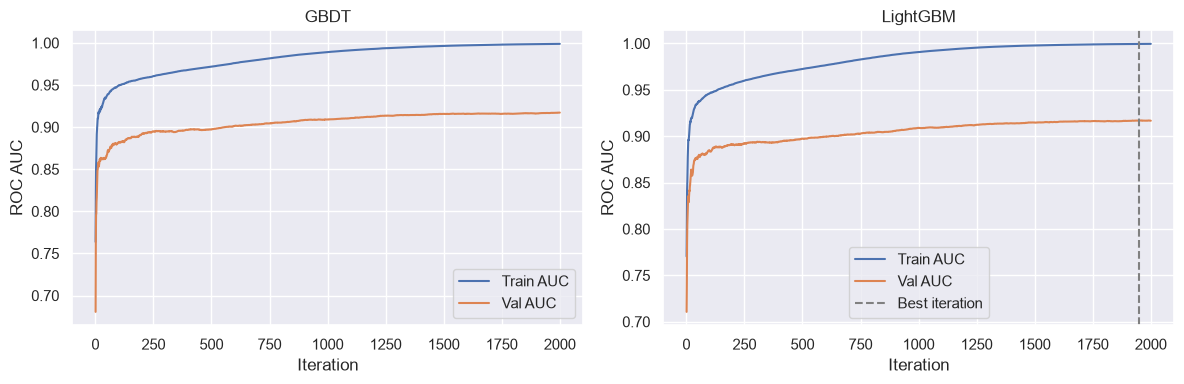

Пайплайн завершён. Предсказания и таблица метрик готовы.


In [42]:
preds_df, metrics_df = run_model_pipeline(
    models, X_train, y_train, X_val, y_val,
    use_cleanlab=False,  # True — сравнить обычную модель и CleanLearning
)

In [43]:
metrics_df

,Model,Started At,Params,Model File,Cleanlab,Seed,Features,Best Iteration,Train AUC,Val AUC,Fit Time (s)
0,GBDT,2026-09-23T23:31:30.422926+03:00,"{'ccp_alpha': 0.0, 'criterion': 'deprecated', ...",pipeline_2026-09-23_23-31-27_672639\03_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",NaN,0.998833,0.917232,73.789
1,LightGBM,2026-09-23T23:32:55.175628+03:00,"{'boosting_type': 'gbdt', 'class_weight': None...",pipeline_2026-09-23_23-31-27_672639\04_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",1950.0,0.999465,0.916952,6.425
2,Random Forest,2026-09-23T23:31:28.062084+03:00,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",pipeline_2026-09-23_23-31-27_672639\02_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",NaN,0.970652,0.885038,1.880
3,Decision Tree,2026-09-23T23:31:27.675483+03:00,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit...",pipeline_2026-09-23_23-31-27_672639\01_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",NaN,0.890544,0.787908,0.360


Лог запуска: C:\Users\peret\Desktop\Third year\ML\comp\comp 1\sbmt_kaggle\logs\pipeline_2026-09-23_23-33-02_219911.json
Пайплайн: 4 моделей | train=(2520, 525), val=(560, 525)

[1/4] Decision Tree
  Вариант: Decision Tree
  Обучение...
  Fit завершён за 0.4 с. Считаю предсказания и AUC...
  Train AUC: 0.92222 | Val AUC: 0.87713
  Извлекаю историю AUC по итерациям...
  Модель готова.
Обученная модель сохранена: logs\pipeline_2026-09-23_23-33-02_219911\01_base.joblib
  Результат сохранён: pipeline_2026-09-23_23-33-02_219911.json

[2/4] Random Forest
  Вариант: Random Forest
  Обучение...
  Fit завершён за 2.2 с. Считаю предсказания и AUC...
  Train AUC: 0.94059 | Val AUC: 0.89441
  Извлекаю историю AUC по итерациям...
  Модель готова.
Обученная модель сохранена: logs\pipeline_2026-09-23_23-33-02_219911\02_base.joblib
  Результат сохранён: pipeline_2026-09-23_23-33-02_219911.json

[3/4] GBDT
  Вариант: GBDT
  Обучение...
  Fit завершён за 66.5 с. Считаю предсказания и AUC...
  Train AUC: 

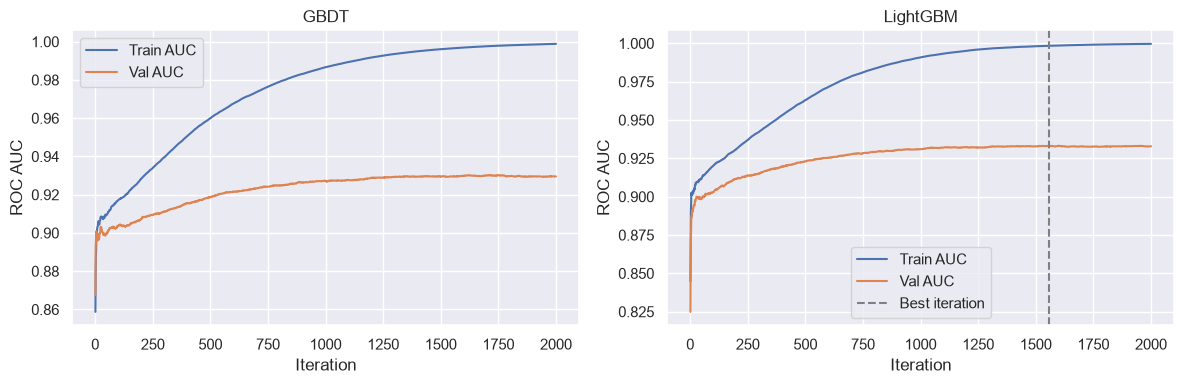

Пайплайн завершён. Предсказания и таблица метрик готовы.


In [44]:
preds_df_extended, metrics_df_extended = run_model_pipeline(
    models, X_train_extended, y_train, X_val_extended, y_val,
    use_cleanlab=False,  # True — сравнить обычную модель и CleanLearning
)

In [45]:
metrics_df_extended

,Model,Started At,Params,Model File,Cleanlab,Seed,Features,Best Iteration,Train AUC,Val AUC,Fit Time (s)
0,LightGBM,2026-09-23T23:34:18.297337+03:00,"{'boosting_type': 'gbdt', 'class_weight': None...",pipeline_2026-09-23_23-33-02_219911\04_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",1556.0,0.998366,0.933240,6.142
1,GBDT,2026-09-23T23:33:05.378810+03:00,"{'ccp_alpha': 0.0, 'criterion': 'deprecated', ...",pipeline_2026-09-23_23-33-02_219911\03_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",NaN,0.998846,0.929541,66.472
2,Random Forest,2026-09-23T23:33:02.602140+03:00,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",pipeline_2026-09-23_23-33-02_219911\02_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",NaN,0.940593,0.894413,2.174
3,Decision Tree,2026-09-23T23:33:02.223067+03:00,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit...",pipeline_2026-09-23_23-33-02_219911\01_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",NaN,0.922216,0.877130,0.353


## Пайплайн с 

## Эксперимент: log1p → StandardScaler → RBF SVC

Используем `X_train_extended`, `X_val_extended`, `X_test_extended` из Feature Engineering. SVC — самостоятельная модель, GBDT здесь не участвует.

CV ROC-AUC считаем по `decision_function`. Все преобразования обучаются внутри фолдов. Затем калибруем вероятности на train для `predict_proba` и submission; validation в обучении и калибровке не участвует. Сохраняем весь конвейер, поэтому при загрузке передаём extended-признаки **без ручного log1p и масштабирования**.

In [22]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score
from datetime import datetime
import json
import time
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ==============================================================================
# 1. КАСТОМНЫЙ ТРАНСФОРМЕР ВЗВЕШИВАНИЯ ПРИЗНАКОВ (FEATURE WEIGHTING)
# ==============================================================================

class UnivariateFeatureWeighter(BaseEstimator, TransformerMixin):
    """
    Трансформер взвешивает признаки перед RBF SVC на основе их одномерного ROC-AUC.
    w_j = |AUC_j - 0.5|^alpha
    
    При alpha = 0.0 -> все веса = 1.0 (обычный SVC)
    При alpha > 0.0 -> сильные признаки получают больший вес в RBF-расстоянии
    """
    def __init__(self, alpha=0.5, score_type='auc', top_k=None):
        self.alpha = alpha
        self.score_type = score_type
        self.top_k = top_k  # Можно совместить с top-K отбором (None = оставить все)
        self.weights_ = None
        self.selected_indices_ = None

    def fit(self, X, y):
        X_arr = np.asarray(X)
        y_arr = np.asarray(y)
        n_features = X_arr.shape[1]
        scores = np.zeros(n_features)

        if self.score_type == 'auc':
            for j in range(n_features):
                feature_col = X_arr[:, j]
                # Считаем ROC-AUC для отдельного признака
                try:
                    auc = roc_auc_score(y_arr, feature_col)
                except ValueError:
                    auc = 0.5
                # Сигнал — отклонение от 0.5 (случайного угадывания)
                scores[j] = abs(auc - 0.5)
                
        elif self.score_type == 'd_stat':
            # Статистика Коэна (d_j = |mean_0 - mean_1| / std_j)
            mask_0 = (y_arr == 0)
            mask_1 = (y_arr == 1)
            std_total = np.std(X_arr, axis=0) + 1e-8
            mean_diff = np.abs(np.mean(X_arr[mask_0], axis=0) - np.mean(X_arr[mask_1], axis=0))
            scores = mean_diff / std_total

        # Отбор Top-K если задан
        if self.top_k is not None and self.top_k < n_features:
            self.selected_indices_ = np.argsort(scores)[::-1][:self.top_k]
            scores = scores[self.selected_indices_]
        else:
            self.selected_indices_ = np.arange(n_features)

        # Вычисление весов w_j = score^alpha
        if self.alpha == 0.0:
            self.weights_ = np.ones_like(scores)
        else:
            # Нормируем максимальный вес в 1.0 для стабильности RBF gamma
            max_score = np.max(scores) + 1e-8
            norm_scores = scores / max_score
            self.weights_ = np.power(norm_scores, self.alpha)

        return self

    def transform(self, X):
        X_arr = np.asarray(X)
        # Фильтрация по top_k
        X_sub = X_arr[:, self.selected_indices_]
        # Взвешивание z_j <- z_j * w_j
        return X_sub * self.weights_

In [53]:
# ==============================================================================
# 2. ПОДБОР HYPERPARAMETERS ЧЕРЕЗ OPTUNA (ALPHA + TOP_K + SVC)
# ==============================================================================


# Проверки данных перед стартом
for name, features in [('train', X_train), ('val', X_val), ('test', X_test)]:
    if not np.isfinite(features.to_numpy()).all() or (features < 0).any().any():
        raise ValueError(f'{name}: нужны конечные неотрицательные признаки')
    if list(features.columns) != list(X_train.columns):
        raise ValueError(f'{name}: порядок признаков отличается от train')

print(f'Старт подбора Weighted RBF SVC. Признаков: {X_train.shape[1]}')

def objective(trial):
    n_features_total = X_train.shape[1]

    # --- Параметры взвешивания ---
    alpha = trial.suggest_float('alpha', 0.0, 1.5)  # 0.0 = без весов, 0.25, 0.5, 1.0, 1.5
    score_type = trial.suggest_categorical('score_type', ['auc', 'd_stat'])
    
    use_top_k = trial.suggest_categorical('use_top_k', [True, False])
    top_k = trial.suggest_int('top_k', 150, n_features_total) if use_top_k else None

    # --- Параметры RBF SVC ---
    C = trial.suggest_float('C', 1e-1, 100.0, log=True)
    gamma_type = trial.suggest_categorical('gamma_type', ['scale', 'auto', 'custom'])
    gamma = trial.suggest_float('gamma_value', 1e-4, 1.0, log=True) if gamma_type == 'custom' else gamma_type

    pipeline = Pipeline([
        ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('fe', FullFeatureEngineering(n_splits=5)),
        ('scaler', StandardScaler()),
        ('weighter', UnivariateFeatureWeighter(alpha=alpha, score_type=score_type, top_k=top_k)),
        ('svc', SVC(C=C, kernel='rbf', gamma=gamma, random_state=SEED))
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=60, timeout=500, show_progress_bar=True)

print("\n=== ЛУЧШИЕ ПАРАМЕТРЫ WEIGHTED RBF SVC ===")
print(f"Best CV ROC-AUC: {study.best_value:.5f}")
for k, v in study.best_params.items():
    print(f" - {k}: {v}")

Старт подбора Weighted RBF SVC. Признаков: 512


  0%|          | 0/80 [00:00<?, ?it/s]

Best trial: 30. Best value: 0.928096: 100%|██████████| 80/80 [08:37<00:00,  6.46s/it, 517.19/900 seconds]


=== ЛУЧШИЕ ПАРАМЕТРЫ WEIGHTED RBF SVC ===
Best CV ROC-AUC: 0.92810
 - alpha: 0.10476601539221192
 - score_type: auc
 - use_top_k: False
 - C: 4.452385125114848
 - gamma_type: custom
 - gamma_value: 0.0034659619944963764


In [54]:
# ==============================================================================
# 3. ФИНАЛЬНОЕ ОБУЧЕНИЕ И КАЛИБРОВКА ЛУЧШЕЙ МОДЕЛИ
# ==============================================================================

bp = study.best_params

best_weighter = UnivariateFeatureWeighter(
    alpha=bp['alpha'],
    score_type=bp['score_type'],
    top_k = bp.get('top_k', None) if bp.get('use_top_k', False) else None
)
gamma_best = bp.get('gamma_value', bp.get('gamma_type')) if bp.get('gamma_type') == 'custom' else bp.get('gamma_type')

best_svc_pipeline = Pipeline([
    ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('fe', FullFeatureEngineering(n_splits=5)),
    ('scaler', StandardScaler()),
    ('weighter', best_weighter),
    ('svc', SVC(C=bp['C'], kernel='rbf', gamma=gamma_best, random_state=SEED))
])

svc_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
svc_cv_scores = cross_val_score(best_svc_pipeline, X_train, y_train, cv=svc_cv, scoring='roc_auc', n_jobs=-1)

svc_model = CalibratedClassifierCV(
    estimator=best_svc_pipeline, method='sigmoid', cv=svc_cv, ensemble=False
)

svc_started_at = datetime.now().astimezone()
svc_start = time.perf_counter()
svc_model.fit(X_train, y_train)
svc_fit_time = time.perf_counter() - svc_start

svc_train_probs = svc_model.predict_proba(X_train)[:, 1]
svc_val_probs = svc_model.predict_proba(X_val)[:, 1]

svc_metrics = pd.DataFrame([{
    'Model': f"Weighted RBF SVC (alpha={bp['alpha']:.2f}, {bp['score_type']})",
    'CV AUC': svc_cv_scores.mean(),
    'CV STD': svc_cv_scores.std(),
    'Train AUC': roc_auc_score(y_train, svc_train_probs),
    'Val AUC': roc_auc_score(y_val, svc_val_probs),
    'Fit Time (s)': round(svc_fit_time, 3),
}])

display(svc_metrics)

,Model,CV AUC,CV STD,Train AUC,Val AUC,Fit Time (s)
0,"Weighted RBF SVC (alpha=0.10, auc)",0.928096,0.004317,1.0,0.948992,23.649


In [ ]:
# Выполни эти строки, когда понадобится файл для Kaggle:
submission_svc = save_submission(
    svc_model, X_test_extended, test_df['row_id'], sample_submission,
    OUTPUT_DIR / 'submission_svc_extended.csv',
)

In [56]:
# ==============================================================================
# 3. ФИНАЛЬНОЕ ОБУЧЕНИЕ НА СУММАРНОЙ ВЫБОРКЕ (TRAIN + VAL) И СОХРАНЕНИЕ
# ==============================================================================

# Объединяем обучающую и валидационную выборки в один датасет
X_full_extended = pd.concat([X_train, X_val], axis=0, ignore_index=True)
y_full = pd.concat([y_train, y_val], axis=0, ignore_index=True)

bp = study.best_params

# Безопасное извлечение параметров
top_k_best = bp['top_k'] if bp.get('use_top_k', False) else None
gamma_best = bp['gamma_value'] if bp.get('gamma_type') == 'custom' else bp['gamma_type']

best_weighter = UnivariateFeatureWeighter(
    alpha=bp['alpha'],
    score_type=bp['score_type'],
    top_k=top_k_best
)

best_svc_pipeline = Pipeline([
    ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('fe', FullFeatureEngineering(n_splits=5)),
    ('scaler', StandardScaler()),
    ('weighter', best_weighter),
    ('svc', SVC(C=bp['C'], kernel='rbf', gamma=gamma_best, random_state=SEED))
])

# Калибровка вероятностей с кросс-валидацией по объединенной выборке
svc_full_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

svc_model = CalibratedClassifierCV(
    estimator=best_svc_pipeline, method='sigmoid', cv=svc_full_cv, ensemble=False
)

print(f"Старт обучения Weighted RBF SVC на Train+Val ({X_full_extended.shape[0]} объектов)...")
svc_start = time.perf_counter()
svc_model.fit(X_full_extended, y_full)
svc_fit_time = time.perf_counter() - svc_start
print(f"Обучение завершено за {svc_fit_time:.2f} сек.")

# Сохранение сабмишна
submission_svc = save_submission(
    svc_model, X_test, test_df['row_id'], sample_submission,
    OUTPUT_DIR / 'submission_svc_all.csv',
)

Старт обучения Weighted RBF SVC на Train+Val (3080 объектов)...
Обучение завершено за 27.35 сек.
Предсказываю для 1116 строк...
Сохранено: C:\Users\peret\Desktop\Third year\ML\comp\comp 1\sbmt_kaggle\submission_svc_all.csv | (1116, 2)


In [51]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.calibration import CalibratedClassifierCV

svc_pipeline = Pipeline([
    ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('fe', FullFeatureEngineering(n_splits=5)),
    ('scaler', StandardScaler()),
    ('svc', SVC(C=10, kernel='rbf', gamma='scale')),
])
svc_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, features in [('train', X_train), ('val', X_val),
                       ('test', X_test)]:
    if not np.isfinite(features.to_numpy()).all() or (features < 0).any().any():
        raise ValueError(f'{name}: для этого эксперимента нужны конечные неотрицательные признаки')
    if list(features.columns) != list(X_train.columns):
        raise ValueError(f'{name}: состав или порядок признаков отличается от train')
print(f'SVC: {X_train.shape[1]} признаков')

SVC: 512 признаков


In [52]:
svc_cv_scores = cross_val_score(
    svc_pipeline, X_train, y_train,
    cv=svc_cv, scoring='roc_auc', n_jobs=1,
)
print('CV AUC по фолдам:', np.round(svc_cv_scores, 5))
print(f'CV AUC: {svc_cv_scores.mean():.5f} ± {svc_cv_scores.std():.5f}')

CV AUC по фолдам: [0.92337 0.91717 0.92577 0.93353 0.92572]
CV AUC: 0.92511 ± 0.00525


In [33]:
# Калибруется весь Pipeline: scaler обучается заново внутри каждого фолда.
# ensemble=False: итоговая SVC обучается на всём train.
svc_model = CalibratedClassifierCV(
    estimator=svc_pipeline, method='sigmoid', cv=svc_cv, ensemble=False,
)
svc_started_at = datetime.now().astimezone()
svc_start = time.perf_counter()
svc_model.fit(X_train_extended, y_train)
svc_fit_time = time.perf_counter() - svc_start

svc_train_probs = svc_model.predict_proba(X_train_extended)[:, 1]
svc_val_probs = svc_model.predict_proba(X_val_extended)[:, 1]
svc_metrics = pd.DataFrame([{
    'Model': 'log1p + StandardScaler + RBF SVC (extended)',
    'CV AUC (decision_function)': svc_cv_scores.mean(),
    'CV STD': svc_cv_scores.std(),
    'Train AUC': roc_auc_score(y_train, svc_train_probs),
    'Val AUC': roc_auc_score(y_val, svc_val_probs),
    'Fit + Calibration Time (s)': round(svc_fit_time, 3),
}])

svc_run_dir = LOG_DIR / f'svc_{svc_started_at:%Y-%m-%d_%H-%M-%S_%f}'
svc_model_path = save_model(svc_model, svc_run_dir / 'model.joblib')
svc_log = {
    'run_started_at': svc_started_at.isoformat(),
    'feature_columns': list(X_train_extended.columns),
    'params': {'C': 10, 'kernel': 'rbf', 'gamma': 'scale'},
    'preprocessing': ['log1p', 'StandardScaler'],
    'calibration': {'method': 'sigmoid', 'ensemble': False, 'folds': 5},
    'seed': SEED,
    'cv_scores': svc_cv_scores.tolist(),
    'results': [{
        **json.loads(svc_metrics.to_json(orient='records'))[0],
        'Model File': 'model.joblib',
    }],
}
(svc_run_dir / 'results.json').write_text(
    json.dumps(svc_log, ensure_ascii=False, indent=2), encoding='utf-8',
)
pd.DataFrame({
    'row_id': val_df['row_id'], 'target': y_val, 'prediction': svc_val_probs,
}).to_csv(svc_run_dir / 'validation_predictions.csv', index=False)
print(f'Результаты: {svc_run_dir.resolve()}')
display(svc_metrics)

Обученная модель сохранена: logs\svc_2026-09-23_23-25-09_025920\model.joblib
Результаты: C:\Users\peret\Desktop\Third year\ML\comp\comp 1\sbmt_kaggle\logs\svc_2026-09-23_23-25-09_025920


,Model,CV AUC (decision_function),CV STD,Train AUC,Val AUC,Fit + Calibration Time (s)
0,log1p + StandardScaler + RBF SVC (extended),0.927882,0.00444,1.0,0.948316,5.884


In [ ]:
# Выполни эти строки, когда понадобится файл для Kaggle:
# submission_svc = save_submission(
#     svc_model, X_test_extended, test_df['row_id'], sample_submission,
#     OUTPUT_DIR / 'submission_svc_extended.csv',
# )

# После перезапуска ядра можно загрузить весь обученный конвейер:
# svc_model = load_model(svc_run_dir / 'results.json', svc_log['results'][0]['Model'])

## Поиск параметров
Включается флагом `RUN_SEARCH` в настройках.
CV здесь — дополнительная диагностика. Основное сравнение моделей по условиям соревнования — на supplied validation, отделённом по скрытым сущностям.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
param_grids = {
    'Random Forest': {
        'n_estimators': [300, 500, 800, 1000, 1100, 1200, 1300, 1400, 1500, 1700, 1800, 2000],
        'max_depth': [5, 10, 15],
        'min_samples_split': [5, 10, 20, 50],
        'min_samples_leaf': [5, 10, 20],
        'max_features': ['sqrt', 'log2', 0.3, 0.5],
    },

    'GBDT': {
        'n_estimators': [2000, 2200, 2500],
        'learning_rate': [0.05, 0.1, 0.15, 0.2],
        'max_depth': [3, 4, 5],
        'min_samples_split': [5],
        'min_samples_leaf': [10, 20, 30],
        'max_features': ['sqrt', 0.1, 0.3, 0.5],
        'subsample': [0.6, 0.8],
    },
    'LightGBM': {
        'n_estimators': [1000, 1500, 2000, 2500],
        'learning_rate': [0.02, 0.03, 0.05],
        'max_depth': [4, 5, 6, 7],
        'num_leaves': [7, 15, 16],
        'min_child_samples': [20, 30, 50, 80],
        'subsample': [0.6, 0.7, 0.8],
        'colsample_bytree': [0.5, 0.7, 0.9],
        'reg_alpha': [0.0, 0.01, 0.1],
        'reg_lambda': [0.0, 0.01, 0.1, 1.0],
    },
}

In [ ]:
preds_df_search = metrics_df_search = None
if RUN_SEARCH:
    preds_df_search, metrics_df_search = run_model_pipeline_search(
        models, param_grids, X_train, y_train, X_val, y_val,
        n_iter=30, cv=cv, scoring='roc_auc', plot_curves=True,
        verbose=10, n_jobs=-1,
    )
    display(metrics_df_search)

## Эксперименты с CleanLearning
Включаются флагом `RUN_CLEANLAB` в настройках.

In [ ]:
if RUN_CLEANLAB:
    model = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=50, min_samples_leaf=20, random_state=SEED, n_jobs=-1)
    cl = cleanlab.classification.CleanLearning(model, seed=SEED, verbose=True)
    cl.fit(X_train, y_train)
    model = clone(model)
    model.fit(X_train, y_train)

    # issues = cl.get_label_issues()
    # print(issues['is_label_issue'].sum())
    print("Val AUC (cleaned):", roc_auc_score(y_val, cl.predict_proba(X_val)[:, 1]))
    print('Val AUC (model):', roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
    print('model params:', model.get_params())

In [ ]:
# True — сравнить обычную модель и CleanLearning.
if RUN_CLEANLAB:
    models_clean = {'LightGBM': models['LightGBM']}
    preds_df_clean, metrics_df_clean = run_model_pipeline(
        models_clean, X_train, y_train, X_val, y_val, use_cleanlab=True,
    )
    display(metrics_df_clean)

## Предсказания сохранённой модели
По умолчанию сохраняется submission GBDT из текущего extended-запуска. Для загрузки исторической модели укажи JSON_PATH. В этом режиме достаточно настройки, подготовки данных и функций сохранения/загрузки.

In [ ]:
# По умолчанию используем GBDT из текущего запуска на extended-признаках.
# Для отдельной загрузки старого запуска явно укажи JSON_PATH.
JSON_PATH = None  # Например: LOG_DIR / 'pipeline_2026-09-19_20-51-16_279271.json'
MODEL_NAME = 'GBDT'  # Например: 'Random Forest + Cleanlab'
SUBMISSION_PATH = OUTPUT_DIR / 'submission_GBDT_extended.csv'

if JSON_PATH is None:
    model_info = metrics_df_extended.loc[metrics_df_extended['Model'] == MODEL_NAME].iloc[0]
    selected_model = joblib.load(LOG_DIR / model_info['Model File'])
else:
    selected_model = load_model(JSON_PATH, MODEL_NAME)
submission = save_submission(
    selected_model, X_test_extended, test_df['row_id'], sample_submission, SUBMISSION_PATH,
)
display(submission.head())

### Нейронка

In [47]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.preprocessing import QuantileTransformer, StandardScaler, RobustScaler
import torch.nn as nn
import torch.optim as optim
import os

def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    # Флаги детерминированности cuDNN
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Фиксируем всё
SEED = 451
seed_everything(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Замена StandardScaler на QuantileTransformer (Идеально для нейросетей на табличках)
# Превращает любое распределение признаков в чистое нормальное N(0, 1)
# scaler = QuantileTransformer(output_distribution='normal', random_state=SEED)
# scaler = StandardScaler()
scaler = RobustScaler()

# Предобработка сразу в float32, чтобы экономить память
X_tr_log = np.log1p(np.maximum(0, X_train_extended.to_numpy(dtype=np.float32)))
X_va_log = np.log1p(np.maximum(0, X_val_extended.to_numpy(dtype=np.float32)))
X_te_log = np.log1p(np.maximum(0, X_test_extended.to_numpy(dtype=np.float32)))

X_tr_proc = scaler.fit_transform(X_tr_log)
X_va_proc = scaler.transform(X_va_log)
X_te_proc = scaler.transform(X_te_log)

# Защита от NaN/Inf
X_tr_proc = np.nan_to_num(X_tr_proc)
X_va_proc = np.nan_to_num(X_va_proc)
X_te_proc = np.nan_to_num(X_te_proc)

# 2. Подготовка PyTorch Tensors
X_tr_tensor = torch.from_numpy(X_tr_proc).float()
y_tr_tensor = torch.from_numpy(y_train.to_numpy()).float().unsqueeze(1)

X_va_tensor = torch.from_numpy(X_va_proc).float()
y_va_tensor = torch.from_numpy(y_val.to_numpy()).float().unsqueeze(1)

X_te_tensor = torch.from_numpy(X_te_proc).float()

# 3. Эффективные DataLoader'ы
train_dataset = TensorDataset(X_tr_tensor, y_tr_tensor)
val_dataset = TensorDataset(X_va_tensor, y_va_tensor)

use_cuda = torch.cuda.is_available()

g = torch.Generator()
g.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset, 
    batch_size=64, 
    shuffle=True, 
    drop_last=True,            # Отбрасываем неполный последний батч для стабильности градиентов
    pin_memory=use_cuda,       # Ускоряет передачу данных Host -> GPU
    num_workers=0,              # Можно поставить 2, если обучаешь на Linux/GPU
    generator=g 
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=256, 
    shuffle=False,
    pin_memory=use_cuda
)

C:\Users\peret\AppData\Local\Temp\ipykernel_8640\891521757.py:49: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_tr_tensor = torch.from_numpy(y_train.to_numpy()).float().unsqueeze(1)


In [48]:
# ==============================================================================
# 2. АРХИТЕКТУРА И ИНИЦИАЛИЗАЦИЯ
# ==============================================================================
class TabularMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128, dropout_rate: float = 0.25):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.SiLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)  # Выход — логиты
        )
        self._init_weights()

    def _init_weights(self):
        # Инициализация Kaiming Normal специально под ReLU
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

input_dim = X_train_extended.shape[1]

# Увеличили скрытый слой до 128 (BatchNorm + Dropout не дадут ему переобучиться)
model = TabularMLP(input_dim=input_dim, hidden_dim=256, dropout_rate=0.4).to(device)

criterion = nn.BCEWithLogitsLoss()

# AdamW с увеличенным weight_decay для регулярзации табличных весов
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# Скедулер: снижает LR в 2 раза, если Val AUC не растет 5 эпох
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=4
)

In [49]:
# ==============================================================================
# 3. ЦИКЛ ОБУЧЕНИЯ И ВАЛИДАЦИИ
# ==============================================================================
import copy

EPOCHS = 50
history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}

best_val_auc = 0.0
best_model_weights = None

for epoch in range(1, EPOCHS + 1):
    # ==========================================
    # 1. ОБУЧЕНИЕ
    # ==========================================
    model.train()
    train_loss = 0.0
    train_samples = 0  # Счетчик реального количества объектов
    y_true_train, y_pred_train = [], []
    
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        
        batch_size = batch_x.size(0)
        train_loss += loss.item() * batch_size
        train_samples += batch_size
        
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        y_true_train.extend(batch_y.cpu().numpy())
        y_pred_train.extend(probs)
        
    train_loss /= train_samples  # Исправленное деление
    train_auc = roc_auc_score(y_true_train, y_pred_train)
    
    # ==========================================
    # 2. ВАЛИДАЦИЯ
    # ==========================================
    model.eval()
    val_loss = 0.0
    val_samples = 0
    y_true_val, y_pred_val = [], []
    
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            
            batch_size = batch_x.size(0)
            val_loss += loss.item() * batch_size
            val_samples += batch_size
            
            probs = torch.sigmoid(logits).cpu().numpy()
            y_true_val.extend(batch_y.cpu().numpy())
            y_pred_val.extend(probs)
            
    val_loss /= val_samples
    val_auc = roc_auc_score(y_true_val, y_pred_val)
    
    # ==========================================
    # 3. ШАГ ПЛАНИРОВЩИКА И СОХРАНЕНИЕ ВЕСОВ
    # ==========================================
    scheduler.step(val_auc)
    
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        # Копируем веса, чтобы они не перезаписались на следующей эпохе
        best_model_weights = copy.deepcopy(model.state_dict())
    
    # ==========================================
    # 4. ЛОГИРОВАНИЕ
    # ==========================================
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_auc'].append(train_auc)
    history['val_auc'].append(val_auc)
    
    if epoch % 5 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:02d}/{EPOCHS} | LR: {current_lr:.1e} | "
              f"Train Loss: {train_loss:.4f} | Train AUC: {train_auc:.5f} | "
              f"Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.5f}")

# Загружаем лучшие веса обратно в модель после завершения всех эпох
print(f"\nОбучение завершено. Лучший Val AUC: {best_val_auc:.5f}. Восстановление лучших весов...")
model.load_state_dict(best_model_weights)

Epoch 01/50 | LR: 1.0e-04 | Train Loss: 0.6256 | Train AUC: 0.73176 | Val Loss: 0.5204 | Val AUC: 0.82296
Epoch 05/50 | LR: 1.0e-04 | Train Loss: 0.4368 | Train AUC: 0.87678 | Val Loss: 0.4150 | Val AUC: 0.88802
Epoch 10/50 | LR: 1.0e-04 | Train Loss: 0.3602 | Train AUC: 0.91902 | Val Loss: 0.3769 | Val AUC: 0.90908
Epoch 15/50 | LR: 1.0e-04 | Train Loss: 0.3199 | Train AUC: 0.93847 | Val Loss: 0.3619 | Val AUC: 0.91750
Epoch 20/50 | LR: 1.0e-04 | Train Loss: 0.2848 | Train AUC: 0.95337 | Val Loss: 0.3512 | Val AUC: 0.92134
Epoch 25/50 | LR: 1.0e-04 | Train Loss: 0.2485 | Train AUC: 0.96647 | Val Loss: 0.3468 | Val AUC: 0.92383
Epoch 30/50 | LR: 1.0e-04 | Train Loss: 0.2185 | Train AUC: 0.97563 | Val Loss: 0.3490 | Val AUC: 0.92448
Epoch 35/50 | LR: 1.0e-04 | Train Loss: 0.2086 | Train AUC: 0.97812 | Val Loss: 0.3475 | Val AUC: 0.92538
Epoch 40/50 | LR: 1.0e-04 | Train Loss: 0.1849 | Train AUC: 0.98431 | Val Loss: 0.3498 | Val AUC: 0.92591
Epoch 45/50 | LR: 5.0e-05 | Train Loss: 0.1619

<All keys matched successfully>

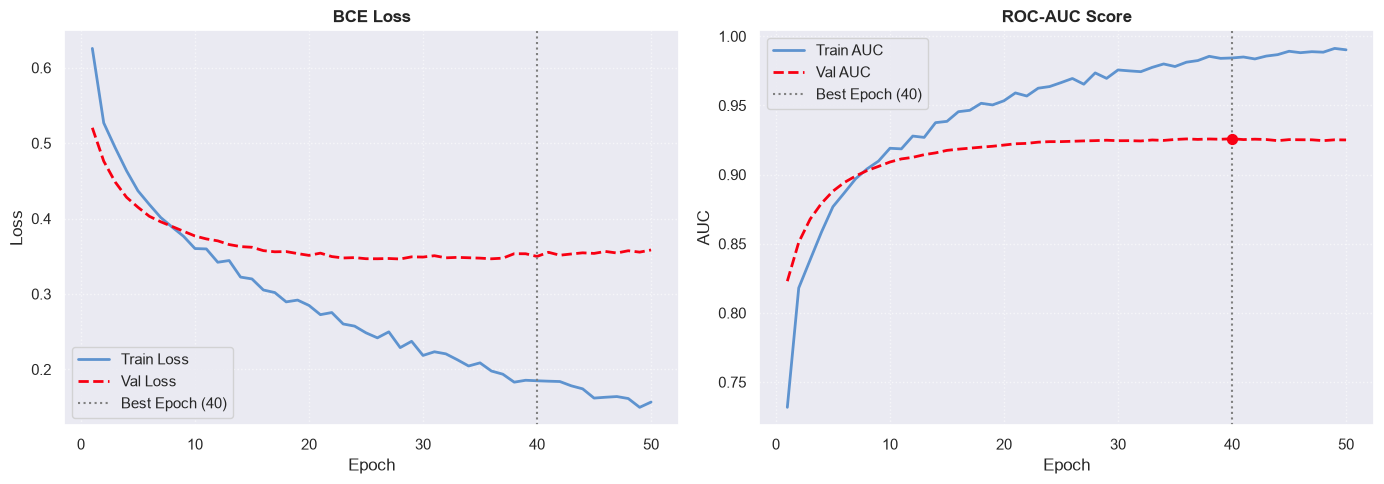

In [50]:
# ==============================================================================
# 4. ПОСТРОЕНИЕ ГРАФИКА ОБУЧЕНИЯ
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

color_train = '#5E93CF'
color_val = '#F80012'
epochs_range = range(1, EPOCHS + 1)

# Индекс эпохи с лучшим Val AUC для отметки на графике
best_epoch = np.argmax(history['val_auc']) + 1

# График Loss
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', color=color_train, linewidth=2)
axes[0].plot(epochs_range, history['val_loss'], label='Val Loss', color=color_val, linewidth=2, linestyle='--')
axes[0].axvline(best_epoch, color='gray', linestyle=':', label=f'Best Epoch ({best_epoch})')
axes[0].set_title('BCE Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# График ROC-AUC
axes[1].plot(epochs_range, history['train_auc'], label='Train AUC', color=color_train, linewidth=2)
axes[1].plot(epochs_range, history['val_auc'], label='Val AUC', color=color_val, linewidth=2, linestyle='--')
axes[1].axvline(best_epoch, color='gray', linestyle=':', label=f'Best Epoch ({best_epoch})')
axes[1].scatter([best_epoch], [best_val_auc], color=color_val, s=50, zorder=5)
axes[1].set_title('ROC-AUC Score', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================
# 5. ТЕСТОВЫЕ ПРЕДСКАЗАНИЯ
# ==============================================================================
model.eval()

# Быстрый трансфер без копирования через from_numpy
X_test_tensor = torch.from_numpy(X_te_proc).float().to(device)

with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_probs = torch.sigmoid(test_logits).cpu().numpy().flatten()

print(f"\nПредсказания для теста готовы! Обработано объектов: {len(test_probs)}")
print("Первые 5 вероятностей:", np.round(test_probs[:5], 5))